In [ ]:
pip install --upgrade torch torchvision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 532.3/532.3 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.2/366.2 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.1/170.1 MB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.0/206.0 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 201.5/201.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 86.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 MB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 105.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.1/214.1 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 58.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.5/59.5 MB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.9/

In [1]:
import os
import json

# Substitua com seu username do Kaggle
kaggle_config = {
    "username": "pemenezes",
    "key": "KGAT_31600a615ce8c9c728efd3e9e087b6b87"
}

os.makedirs("/root/.kaggle", exist_ok=True)
with open("/root/.kaggle/kaggle.json", "w") as f:
    json.dump(kaggle_config, f)
os.chmod("/root/.kaggle/kaggle.json", 0o600)

print("Configurado!")

Configurado!


In [2]:
!pip install kaggle -q
!kaggle datasets download -d abdelghaniaaba/wildfire-prediction-dataset
!unzip -q wildfire-prediction-dataset.zip -d datas2/
!find datas2 -type d

Dataset URL: https://www.kaggle.com/datasets/abdelghaniaaba/wildfire-prediction-dataset
License(s): other
100% 1.45G/1.45G [01:26<00:00, 17.9MB/s]

datas2
datas2/valid
datas2/valid/nowildfire
datas2/valid/wildfire
datas2/test
datas2/test/nowildfire
datas2/test/wildfire
datas2/train
datas2/train/nowildfire
datas2/train/wildfire


In [3]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Device — usa GPU se disponível
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando: {DEVICE}")

# Caminhos no Colab
TRAIN_DIR = "/content/datas2/train"
VAL_DIR   = "/content/datas2/valid"
TEST_DIR  = "/content/datas2/test"

# Hiperparâmetros
IMG_SIZE   = 224
BATCH_SIZE = 32

# Transformações
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# Datasets
train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transforms)
val_dataset   = datasets.ImageFolder(VAL_DIR,   transform=val_test_transforms)
test_dataset  = datasets.ImageFolder(TEST_DIR,  transform=val_test_transforms)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# Classes
CLASS_NAMES = train_dataset.classes
NUM_CLASSES = len(CLASS_NAMES)

print(f"Classes:  {CLASS_NAMES}")
print(f"Train:    {len(train_dataset)} imagens")
print(f"Val:      {len(val_dataset)} imagens")
print(f"Test:     {len(test_dataset)} imagens")

imgs, labels = next(iter(train_loader))
print(f"\nBatch shape:  {imgs.shape}")
print(f"Labels shape: {labels.shape}")
print(f"Min/Max:      {imgs.min():.2f} / {imgs.max():.2f}")

Usando: cuda
Classes:  ['nowildfire', 'wildfire']
Train:    30250 imagens
Val:      6300 imagens
Test:     6300 imagens

Batch shape:  torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])
Min/Max:      -2.12 / 2.64


In [4]:
import torch.nn as nn

# ── CNN 1 — SimpleFireNet (baseline, mais simples) ──────────────────────────
class SimpleFireNet(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.features = nn.Sequential(
            # Bloco 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),             # 224 → 112

            # Bloco 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),             # 112 → 56
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 56 * 56, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


# ── CNN 2 — DeepFireNet (mais robusta, com Batch Normalization) ──────────────
class DeepFireNet(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.features = nn.Sequential(
            # Bloco 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),             # 224 → 112

            # Bloco 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),             # 112 → 56

            # Bloco 3 — exclusivo da DeepFireNet
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),             # 56 → 28
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


# ── Verificação rápida ───────────────────────────────────────────────────────
simple = SimpleFireNet(NUM_CLASSES).to(DEVICE)
deep   = DeepFireNet(NUM_CLASSES).to(DEVICE)

dummy = torch.randn(1, 3, 224, 224).to(DEVICE)

out_simple = simple(dummy)
out_deep   = deep(dummy)

total_simple = sum(p.numel() for p in simple.parameters())
total_deep   = sum(p.numel() for p in deep.parameters())

print(f"SimpleFireNet → output: {out_simple.shape} | parâmetros: {total_simple:,}")
print(f"DeepFireNet   → output: {out_deep.shape}   | parâmetros: {total_deep:,}")
print("Modelos prontos!")

SimpleFireNet → output: torch.Size([1, 2]) | parâmetros: 51,400,386
DeepFireNet   → output: torch.Size([1, 2])   | parâmetros: 51,606,274
Modelos prontos!


In [5]:
from google.colab import drive
drive.mount('/content/drive')

# Cria pasta para o projeto na Drive
import os
os.makedirs("/content/drive/MyDrive/GS_ACV", exist_ok=True)

Mounted at /content/drive


In [6]:
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
import time

from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

def treinar_modelo(modelo, nome, epochs=30):
    modelo = modelo.to(DEVICE)
    criterio  = nn.CrossEntropyLoss()
    otimizador = optim.Adam(modelo.parameters(), lr=1e-3)
    scheduler  = ReduceLROnPlateau(otimizador, patience=3, factor=0.5)

    historico = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    melhor_acc = 0.0
    patience_counter = 0
    EARLY_STOP = 5

    print(f"\n{'='*50}")
    print(f"Treinando: {nome}")
    print(f"{'='*50}")

    for epoch in range(epochs):
        inicio = time.time()

        # ── Treino ──────────────────────────────────────
        modelo.train()
        loss_treino, acertos, total = 0, 0, 0

        for imgs, labels in train_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            otimizador.zero_grad()
            saidas = modelo(imgs)
            loss   = criterio(saidas, labels)
            loss.backward()
            otimizador.step()

            loss_treino += loss.item()
            acertos     += (saidas.argmax(1) == labels).sum().item()
            total       += labels.size(0)

        acc_treino  = acertos / total
        loss_treino = loss_treino / len(train_loader)

        # ── Validação ────────────────────────────────────
        modelo.eval()
        loss_val, acertos_val, total_val = 0, 0, 0

        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                saidas = modelo(imgs)
                loss   = criterio(saidas, labels)
                loss_val    += loss.item()
                acertos_val += (saidas.argmax(1) == labels).sum().item()
                total_val   += labels.size(0)

        acc_val  = acertos_val / total_val
        loss_val = loss_val / len(val_loader)

        # ── Histórico ────────────────────────────────────
        historico["train_loss"].append(loss_treino)
        historico["val_loss"].append(loss_val)
        historico["train_acc"].append(acc_treino)
        historico["val_acc"].append(acc_val)

        scheduler.step(loss_val)

        duracao = time.time() - inicio
        print(f"Época {epoch+1:02d}/{epochs} | "
              f"Loss treino: {loss_treino:.4f} | Acc treino: {acc_treino:.4f} | "
              f"Loss val: {loss_val:.4f} | Acc val: {acc_val:.4f} | "
              f"{duracao:.0f}s")

        # ── Salva melhor modelo ───────────────────────────
        if acc_val > melhor_acc:
            melhor_acc = acc_val
            torch.save(modelo.state_dict(), f"/content/drive/MyDrive/GS_ACV/{nome}_melhor.pth")
            print(f"  ✓ Melhor modelo salvo (acc val: {melhor_acc:.4f})")
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= EARLY_STOP:
                print(f"  Early stopping na época {epoch+1}")
                break

    print(f"\nMelhor acc validação ({nome}): {melhor_acc:.4f}")
    return historico


# ── Roda os dois treinos ─────────────────────────────────────────────────────
#historico_simple = treinar_modelo(SimpleFireNet(NUM_CLASSES), "SimpleFireNet")
#historico_deep   = treinar_modelo(DeepFireNet(NUM_CLASSES),   "DeepFireNet")

In [7]:
# Reconstrói históricos a partir do output do treino
historico_simple = {
    "train_loss": [0.3115,0.1960,0.1832,0.1710,0.1681,0.1662,0.1676,0.1593,0.1381,0.1301,0.1287,0.1287,0.1228,0.1232,0.1186,0.1205,0.1165,0.1165,0.1116,0.1147,0.1107,0.1076,0.1065,0.1129,0.1089],
    "val_loss":   [0.1810,0.1530,0.1499,0.1268,0.1819,0.1467,0.1326,0.1495,0.1092,0.1059,0.1069,0.1088,0.0983,0.1032,0.1004,0.0920,0.0986,0.0920,0.1135,0.0884,0.0937,0.0919,0.1023,0.0875,0.1086],
    "train_acc":  [0.9055,0.9280,0.9334,0.9369,0.9373,0.9385,0.9393,0.9416,0.9496,0.9523,0.9523,0.9531,0.9564,0.9557,0.9569,0.9569,0.9576,0.9584,0.9586,0.9590,0.9594,0.9616,0.9610,0.9607,0.9607],
    "val_acc":    [0.9344,0.9432,0.9440,0.9532,0.9381,0.9500,0.9537,0.9394,0.9610,0.9648,0.9625,0.9589,0.9657,0.9659,0.9643,0.9681,0.9635,0.9687,0.9670,0.9698,0.9676,0.9698,0.9610,0.9697,0.9608],
}

historico_deep = {
    "train_loss": [0.4990,0.2365,0.2192,0.2038,0.2005,0.2080,0.1927,0.1753,0.1668,0.1676,0.1436],
    "val_loss":   [0.1790,0.4257,0.1638,0.1545,0.1688,0.1192,0.1193,0.1446,0.1281,0.1835,0.2755],
    "train_acc":  [0.8820,0.9164,0.9229,0.9278,0.9288,0.9302,0.9333,0.9392,0.9422,0.9425,0.9495],
    "val_acc":    [0.9400,0.7846,0.9408,0.9408,0.9500,0.9592,0.9583,0.9465,0.9508,0.9333,0.8948],
}

print("Históricos reconstruídos!")
print(f"SimpleFireNet: {len(historico_simple['train_loss'])} épocas")
print(f"DeepFireNet:   {len(historico_deep['train_loss'])} épocas")

Históricos reconstruídos!
SimpleFireNet: 25 épocas
DeepFireNet:   11 épocas



Resultado no TEST SET — SimpleFireNet
Acurácia: 0.9784 (97.84%)

Relatório por classe:
              precision    recall  f1-score   support

  nowildfire       0.98      0.97      0.98      2820
    wildfire       0.97      0.99      0.98      3480

    accuracy                           0.98      6300
   macro avg       0.98      0.98      0.98      6300
weighted avg       0.98      0.98      0.98      6300



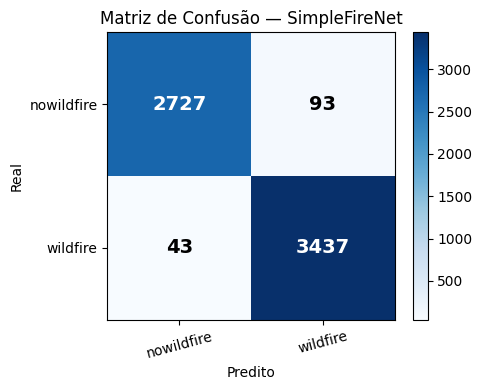


Resultado no TEST SET — DeepFireNet
Acurácia: 0.9676 (96.76%)

Relatório por classe:
              precision    recall  f1-score   support

  nowildfire       0.96      0.97      0.96      2820
    wildfire       0.97      0.97      0.97      3480

    accuracy                           0.97      6300
   macro avg       0.97      0.97      0.97      6300
weighted avg       0.97      0.97      0.97      6300



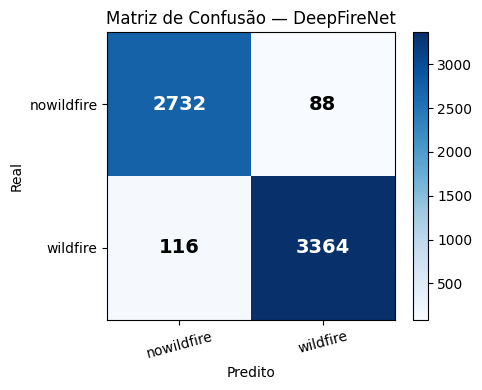

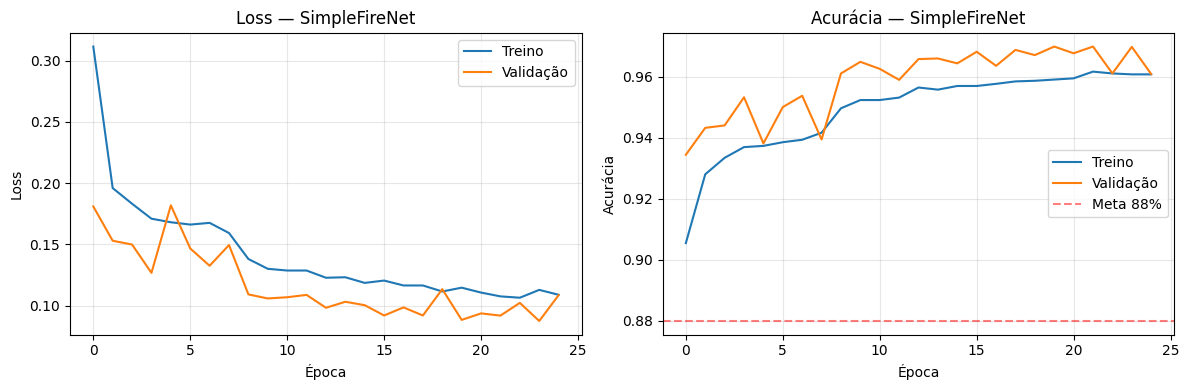

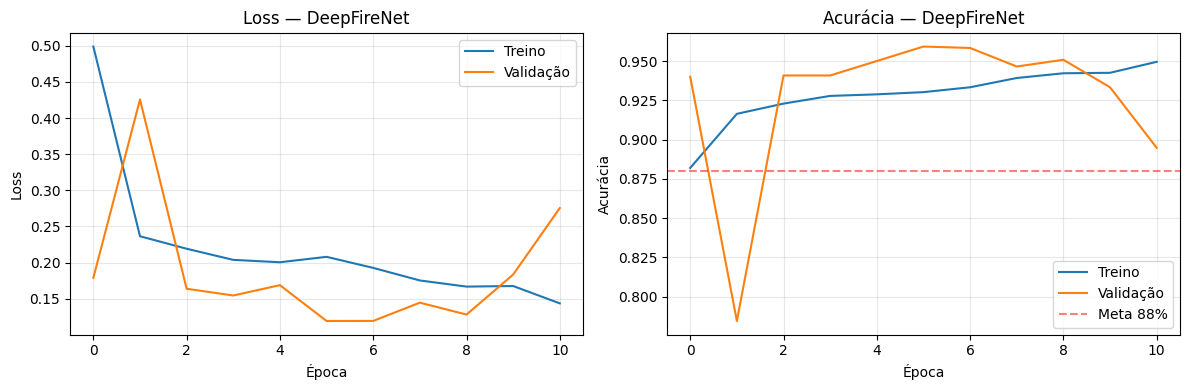


COMPARAÇÃO FINAL
SimpleFireNet — Acc teste: 97.84%
DeepFireNet   — Acc teste: 96.76%

Melhor modelo: SimpleFireNet


In [8]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

def avaliar_modelo(ModelClass, nome_arquivo, nome):
    modelo = ModelClass(NUM_CLASSES).to(DEVICE)
    modelo.load_state_dict(torch.load(
        f"/content/drive/MyDrive/GS_ACV/{nome_arquivo}_melhor.pth",
        map_location=DEVICE
    ))
    modelo.eval()

    todas_preds, todos_labels = [], []
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs = imgs.to(DEVICE)
            saidas = modelo(imgs)
            preds  = saidas.argmax(1).cpu().numpy()
            todas_preds.extend(preds)
            todos_labels.extend(labels.numpy())

    todas_preds  = np.array(todas_preds)
    todos_labels = np.array(todos_labels)
    acc = (todas_preds == todos_labels).mean()

    print(f"\n{'='*50}")
    print(f"Resultado no TEST SET — {nome}")
    print(f"{'='*50}")
    print(f"Acurácia: {acc:.4f} ({acc*100:.2f}%)")
    print(f"\nRelatório por classe:")
    print(classification_report(todos_labels, todas_preds, target_names=CLASS_NAMES))

    # Matriz de confusão
    cm = confusion_matrix(todos_labels, todas_preds)
    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(CLASS_NAMES, rotation=15)
    ax.set_yticklabels(CLASS_NAMES)
    ax.set_xlabel("Predito"); ax.set_ylabel("Real")
    ax.set_title(f"Matriz de Confusão — {nome}")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                    color="white" if cm[i, j] > cm.max()/2 else "black",
                    fontsize=14, fontweight="bold")
    plt.colorbar(im)
    plt.tight_layout()
    plt.savefig(f"/content/drive/MyDrive/GS_ACV/confusion_{nome}.png", dpi=150)
    plt.show()

    return acc, todas_preds, todos_labels


def plotar_historico(historico, nome):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(historico["train_loss"], label="Treino")
    ax1.plot(historico["val_loss"],   label="Validação")
    ax1.set_title(f"Loss — {nome}")
    ax1.set_xlabel("Época"); ax1.set_ylabel("Loss")
    ax1.legend(); ax1.grid(True, alpha=0.3)

    ax2.plot(historico["train_acc"], label="Treino")
    ax2.plot(historico["val_acc"],   label="Validação")
    ax2.axhline(0.88, color="red", linestyle="--", alpha=0.5, label="Meta 88%")
    ax2.set_title(f"Acurácia — {nome}")
    ax2.set_xlabel("Época"); ax2.set_ylabel("Acurácia")
    ax2.legend(); ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"/content/drive/MyDrive/GS_ACV/historico_{nome}.png", dpi=150)
    plt.show()


# Roda avaliação
acc_simple, preds_simple, labels_simple = avaliar_modelo(SimpleFireNet, "SimpleFireNet", "SimpleFireNet")
acc_deep,   preds_deep,   labels_deep   = avaliar_modelo(DeepFireNet,   "DeepFireNet",   "DeepFireNet")

# Plota históricos
plotar_historico(historico_simple, "SimpleFireNet")
plotar_historico(historico_deep,   "DeepFireNet")

# Comparação final
print("\n" + "="*50)
print("COMPARAÇÃO FINAL")
print("="*50)
print(f"SimpleFireNet — Acc teste: {acc_simple*100:.2f}%")
print(f"DeepFireNet   — Acc teste: {acc_deep*100:.2f}%")
vencedor = "SimpleFireNet" if acc_simple > acc_deep else "DeepFireNet"
print(f"\nMelhor modelo: {vencedor}")

In [9]:
import os

arquivos = os.listdir("/content/drive/MyDrive/GS_ACV")
for f in sorted(arquivos):
    print(f)

DeepFireNet_melhor.pth
SimpleFireNet_melhor.pth
confusion_DeepFireNet.png
confusion_SimpleFireNet.png
historico_DeepFireNet.png
historico_SimpleFireNet.png


In [10]:
!pip install gradio -q

import gradio as gr
from PIL import Image
import torch

# Carrega o melhor modelo
modelo_final = SimpleFireNet(NUM_CLASSES).to(DEVICE)
modelo_final.load_state_dict(torch.load(
    "/content/drive/MyDrive/GS_ACV/SimpleFireNet_melhor.pth",
    map_location=DEVICE
))
modelo_final.eval()

def classificar(imagem):
    img = val_test_transforms(imagem).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        saidas = modelo_final(img)
        probs  = torch.softmax(saidas, dim=1)[0]

    return {
        CLASS_NAMES[0]: float(probs[0]),
        CLASS_NAMES[1]: float(probs[1]),
    }

app = gr.Interface(
    fn=classificar,
    inputs=gr.Image(type="pil", label="Imagem de satélite"),
    outputs=gr.Label(num_top_classes=2, label="Classificação"),
    title="🔥 Wildfire Detection — SimpleFireNet",
    description="Classifica imagens de satélite em **wildfire** (queimada ativa) ou **nowildfire**. Projeto Global Solution FIAP 2026.",
    examples=[],
)

app.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://df733ae4137c3414dd.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
